# Time Integration Methods

## Introduction - Non-linear Differential Equations

In the chapter on [diffential equations](Differential_Equations.ipynb), we explored linear ordinary differential equations (ODEs). While linear ODEs can often be solved analytically, using e.g., `sympy.dsolve`, non-linear ODEs typically require numerical methods for their solutions. This chapter focuses on time integration methods specifically designed to handle non-linear differential equations.

### The differential equation

Differential equations model a change of some quantity and are typically expressed along with what is initially known, as so called *initial values (IV)*.  Thus, the *initial value problem (IVP)* we will consider is of the form:

$$
(\mathrm{IVP}) \begin{cases}y^{\prime}(x)=f(x, y) & (\mathrm{ODE}) \\ y\left(x_0\right)=y_0 & (\mathrm{IV})\end{cases} \tag{1a}
$$

or as a system:

$$
(\mathrm{IVP})\left\{\begin{array}{rlr}
y^{\prime}(x) & =f(x, y, v), & y\left(x_0\right)=y_0 \\
v^{\prime}(x) & =f(x, y, v), & v\left(x_0\right)=v_0 \\
& \vdots
\end{array}\right. \tag{1b}
$$

These are solved in parallel with the methods described below for solving (1a).

::: {#exm-simple-ode}

In [1]:
#| echo: false
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import mechanicskit as mk

%config InlineBackend.figure_format = 'svg'

plt.rcParams.update({
    "font.family": "serif",      # Use serif fonts for text
    "mathtext.fontset": "cm",    # 'cm' stands for Computer Modern (Standard LaTeX font)
})

import warnings
warnings.filterwarnings('ignore', message='divide by zero encountered')

In [2]:
#| code-fold: true
x = sp.symbols('x', real=True)
y = sp.Function('y')(x)


In [3]:
#| code-fold: false
DE = sp.Eq(y.diff(x, 1), y)
IV = {y.subs(x, 0): 1}
sp.dsolve(DE, ics=IV)

Eq(y(x), exp(x))

:::

In this chapter, we are interested in studying various numerical methods for solving (1), i.e., finding an approximate solution for the function $y(x), x \geq x_0$. We can say that we want to find a *numerical solution* to the IVP (1).

::: {#thm-CauchyContinuity}

If $f(x, y)$ is continuous then there exist a solution to $y^{\prime}(x)=f(x, y)$. ([Augustin Louis Cauchy](https://en.wikipedia.org/wiki/Augustin-Louis_Cauchy), [Giuseppe Peano](https://en.wikipedia.org/wiki/Giuseppe_Peano)).
:::

::: {#thm-LipschitzContinuity}
Let $f(x, y)$ be continuous for all points $(x, y): a \leq x \leq b,-\infty \leq y \leq \infty$, where $a, b$ are finite. If $f$ satisfies a Lipschitz condition ([Rudolf Lipschitz](https://en.wikipedia.org/wiki/Rudolf_Lipschitz))

$$
\left|f(x, y)-f\left(x, y^*\right)\right| \leq L\left|y-y^*\right| \tag{3}
$$

for $a \leq x \leq b$ and all $y, y^*$, then there exists a unique solution to (1) for every initial value $y\left(x_0\right)=y_0, x_0 \in[a, b]$. The constant $L$ is called the Lipschitz constant.
:::

Unfortunately, most functions $f$ do not satisfy the Lipschitz condition (are Lipschitz continuous), which means that we cannot guarantee the existence of a unique solution for every IVP (1). 

::: {#exm-no-lipschitz}

In [4]:
#| code-fold: false
DE = sp.Eq(y.diff(x, 1), y**2)
IV = {y.subs(x, 0): 1}
sol = sp.dsolve(DE, ics=IV)
sol

Eq(y(x), -1/(x - 1))

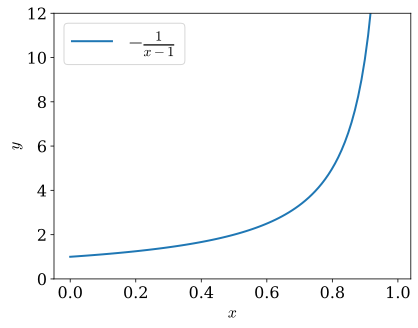

In [10]:
#| code-fold: true
#| classes: size-50
with plt.rc_context({'font.size': 20, 'axes.labelsize': 16, 'xtick.labelsize': 16, 'ytick.labelsize': 16}):
    mk.fplot(sol.rhs, (x, 0, 1), ylabel='$y$', xlabel='$x$', 
            label=f"${sp.latex(sol.rhs)}$",
            lw=2)
    plt.gca().legend()
    plt.gca().set(ylim=(0, 12))
    plt.show()

:::

::: {#thm-LipschitzConstant}
The system of (ODE) $y^{\prime}=\mathbf{A} y$ where $\mathbf{A}$ is a constant matrix has the Lipschitz constant $L=\max
  {\|\mathbf{x}\|=1}\|\mathbf{A} \mathbf{x}\|=\|\mathbf{A}\|_{\infty}=\max _i \sum_j\left|a_{i j}\right|$. There are several matrix norms to choose
  from, but the maximum absolute row sum is good enough. It is also easy to calculate.
:::

::: {#exm-BVP2}
Study the following:

$$
\text { (BVP) } \begin{cases}y^{\prime}(x)=f(x, y)=x y & (\mathrm{ODE}) \\ y(0)=1 & (\mathrm{BV})\end{cases}
$$

and assume that we can solve (BVP) in $x \in[0,1]$. We directly obtain

$$
\left|x y-x y^*\right|=|x|\left|y-y^*\right| \leq 1\left|y-y^*\right|
$$

with the Lipschitz constant $L=1$. In general, one can show that if $\left|\frac{\partial f}{\partial y}\right| \leq L$ in the relevant interval, then $L$ can be used as the Lipschitz constant.
:::

We note that Lipschitz continuity is a constructive concept that can be used, for example, to demonstrate convergence and study the rate of convergence of iterative algorithms, unlike Cauchy's purely existential $\varepsilon, \delta$-exercise that is so common in most analysis courses. Lipschitz continuity is an improvement and stricter than this, and completely dominant in "Computational Mathematics". (R. Lipschitz, Lehrbuch der Analysis, Vol II, 1877)

As we alluded to earlier, we generally cannot expect an analytical solution to a (BVP), but must settle for a purely numerical solution, which is just as good in many aspects. The story goes like this...

## Time integration Methods

We will cover several common stepping methods. The simplest of these, Euler's method, always steps in the current tangent direction. The more sophisticated Heun's method, the Midpoint method, and Runge-Kutta's method choose a more refined way to step. One could say that they perform a reconnaissance and determine directions at one or more points along possible paths before deciding on the final direction for the step. In the methods below, we have chosen a constant step size $h$ for simplicity, but of course it is straightforward to consider a local $h_i$.

## Eulers method

At the initial point $\left(x_0, y_0\right)$ we obtain a tangent direction $y^{\prime}=f\left(x_0, y_0\right)$ from the (ODE). If we step $h$ in $x$ with this direction, we arrive at the point $\left(x_1, y_1\right)$, where $x_1=x_0+h$ and $y_1=y_0+h f\left(x_0, y_0\right)$. We then hope that $y_1 \approx y\left(x_1\right)$. We determine a new direction $y^{\prime}=f\left(x_1, y_1\right)$ from the (ODE), continue the step $h$ in $x$ with this new direction to the point $\left(x_2, y_2\right)$, where $x_2=x_1+h=x_0+2h$ and $y_2=y_1+h f\left(x_1, y_1\right)$ and hope that $y_2 \approx y\left(x_2\right)$, and so on. Again, the Taylor expansion is utilized. Here we truncate directly after the first derivative so that at the point $x_i$ we replace $y^{\prime}\left(x_i\right)$ with a forward difference, whereby the differential equation transforms into

$$
\frac{y\left(x_{i+1}\right)-y\left(x_i\right)}{h} \approx y^{\prime}\left(x_i\right)=f\left(x_i, y_i\right)
$$